#Problem Statement

**Bagaimana dapat memprediksi harga tiket pesawat domestik India berdasarkan atribut penerbangan yang tersedia, sehingga konsumen dan platform travel dapat membuat keputusan pembelian yang lebih baik?**


# Tujuan Bisnis

1. Membangun model prediksi harga tiket
2. Mengidentifikasi faktor-faktor utama yang mempengaruhi harga tiket
3. Memberikan rekomendasi waktu pembelian tiket terbaik
4. Mendukung platform travel dalam memberikan estimasi harga yang relevan

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Bimbing Bootcamp/FINPRO/Clean_Dataset.csv', index_col=0)

print("=" * 55)
print("         DATASET LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  Jumlah Baris (Records) : {df.shape[0]:,}")
print(f"  Jumlah Kolom (Features): {df.shape[1]}")
print("=" * 55)

         DATASET LOADED SUCCESSFULLY
  Jumlah Baris (Records) : 300,153
  Jumlah Kolom (Features): 11


In [ ]:
# Preview Data
print("5 Baris Pertama Dataset:")
df.head()

5 Baris Pertama Dataset:


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
# Preview Tail
print("5 Baris Terakhir Dataset:")
df.tail()

5 Baris Terakhir Dataset:


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [ ]:
# Data Info
print("Informasi Dataset:")
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [ ]:
# Data Dictionary
data_dict = {
    'Kolom': ['airline', 'flight', 'source_city', 'departure_time', 'stops',
              'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price'],
    'Tipe Data': ['Categorical', 'Categorical', 'Categorical', 'Categorical', 'Categorical',
                  'Categorical', 'Categorical', 'Categorical', 'Numerical (float)', 'Numerical (int)', 'Numerical (int)'],
    'Deskripsi': [
        'Nama maskapai penerbangan',
        'Kode penerbangan',
        'Kota asal keberangkatan',
        'Waktu keberangkatan (periode hari)',
        'Jumlah transit/stopover',
        'Waktu kedatangan (periode hari)',
        'Kota tujuan kedatangan',
        'Kelas penerbangan (Economy/Business)',
        'Durasi penerbangan (dalam jam)',
        'Jumlah hari tersisa hingga keberangkatan',
        'Harga tiket pesawat (dalam Rupee India - INR)'
    ],
    'Role': ['Feature', 'Drop (ID)', 'Feature', 'Feature', 'Feature',
             'Feature', 'Feature', 'Feature', 'Feature', 'Feature', 'TARGET']
}

dict_df = pd.DataFrame(data_dict)
print("Data Dictionary:")
dict_df

Data Dictionary:


,Kolom,Tipe Data,Deskripsi,Role
0,airline,Categorical,Nama maskapai penerbangan,Feature
1,flight,Categorical,Kode penerbangan,Drop (ID)
2,source_city,Categorical,Kota asal keberangkatan,Feature
3,departure_time,Categorical,Waktu keberangkatan (periode hari),Feature
4,stops,Categorical,Jumlah transit/stopover,Feature
5,arrival_time,Categorical,Waktu kedatangan (periode hari),Feature
6,destination_city,Categorical,Kota tujuan kedatangan,Feature
7,class,Categorical,Kelas penerbangan (Economy/Business),Feature
8,duration,Numerical (float),Durasi penerbangan (dalam jam),Feature
9,days_left,Numerical (int),Jumlah hari tersisa hingga keberangkatan,Feature


In [ ]:
# Missing Values Analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Pengecekan Missing Values:")
if missing_df.empty:
    print("Tidak ada missing values! Dataset sudah bersih.")
else:
    print(missing_df)

Pengecekan Missing Values:
Tidak ada missing values! Dataset sudah bersih.


In [ ]:
# Duplicate Check
dup_count = df.duplicated().sum()
print(f"Jumlah Baris Duplikat  : {dup_count}")

if dup_count == 0:
    print("Tidak ada data duplikat! Dataset sudah bersih.")
else:
    print(f"Ditemukan {dup_count} data duplikat, perlu ditangani.")
    print("Contoh data duplikat:")
    print(df[df.duplicated()].head())

Jumlah Baris Duplikat  : 0
Tidak ada data duplikat! Dataset sudah bersih.


In [ ]:
# Descriptive Statistics - Numerical
print("Statistik Deskriptif — Kolom Numerik:")
df.describe().round(2)

Statistik Deskriptif — Kolom Numerik:


,duration,days_left,price
count,300153.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00


In [ ]:
# Descriptive Statistics - Categorical
print("Statistik Deskriptif — Kolom Kategorikal:")
df.describe(include='object')

Statistik Deskriptif — Kolom Kategorikal:


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


In [ ]:
# Unique values per categorical column
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('flight')

print("Nilai Unik per Kolom Kategorikal:\n")
for col in cat_cols:
    vals = df[col].unique().tolist()
    print(f"  [{col}] → {len(vals)} nilai unik: {vals}")

Nilai Unik per Kolom Kategorikal:

  [airline] → 6 nilai unik: ['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
  [source_city] → 6 nilai unik: ['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
  [departure_time] → 6 nilai unik: ['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
  [stops] → 3 nilai unik: ['zero', 'one', 'two_or_more']
  [arrival_time] → 6 nilai unik: ['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']
  [destination_city] → 6 nilai unik: ['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
  [class] → 2 nilai unik: ['Economy', 'Business']


# Exploratory Data Analysis (EDA)
Distribusi Target Variable: PRICE


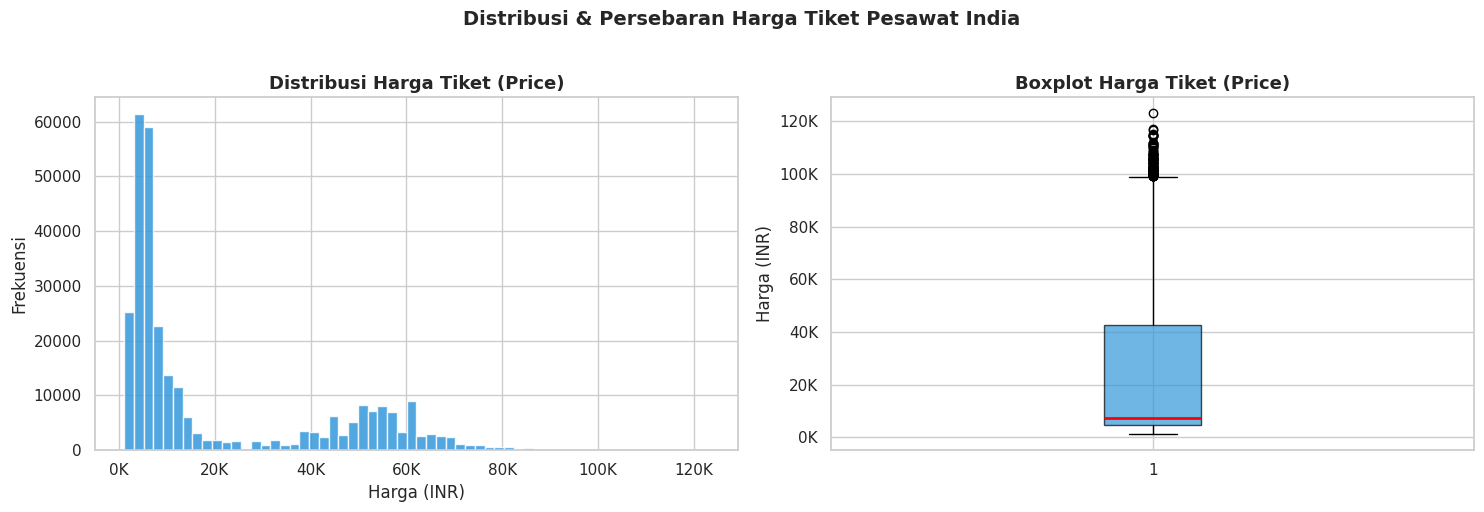


Ringkasan Statistik Harga Tiket:
  Minimum    : INR 1,105
  Maksimum   : INR 123,071
  Rata-rata  : INR 20,890
  Median     : INR 7,425
  Std Dev    : INR 22,698
  Skewness   : 1.061  → Positive skew (right-skewed)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['price'], bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Harga Tiket (Price)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Harga (INR)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Boxplot
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Harga Tiket (Price)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Harga (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Distribusi & Persebaran Harga Tiket Pesawat India', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Stats summary
print("\nRingkasan Statistik Harga Tiket:")
print(f"  Minimum    : INR {df['price'].min():,}")
print(f"  Maksimum   : INR {df['price'].max():,}")
print(f"  Rata-rata  : INR {df['price'].mean():,.0f}")
print(f"  Median     : INR {df['price'].median():,.0f}")
print(f"  Std Dev    : INR {df['price'].std():,.0f}")
print(f"  Skewness   : {df['price'].skew():.3f}  → {'Positive skew (right-skewed)' if df['price'].skew() > 0 else 'Negative skew'}")

Distribusi Fitur Kategorikal

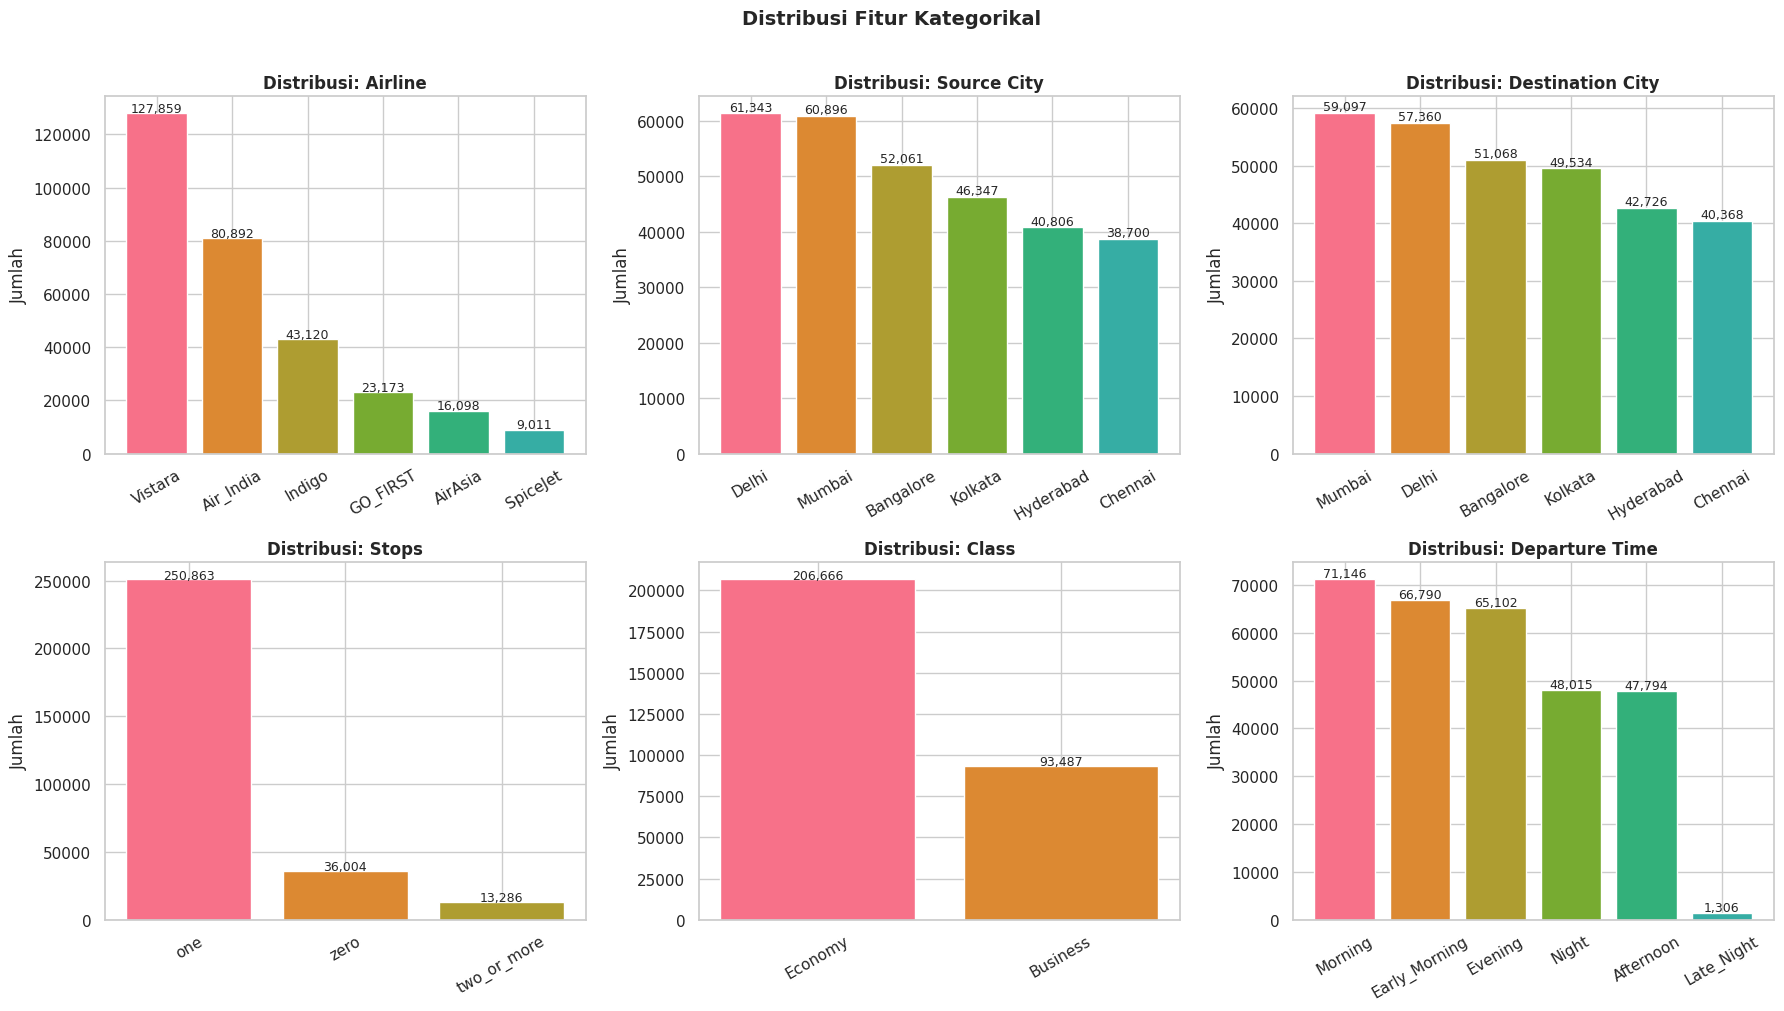

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors_palette = sns.color_palette('husl', 10)

cat_plot_cols = ['airline', 'source_city', 'destination_city', 'stops', 'class', 'departure_time']

for i, col in enumerate(cat_plot_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors_palette[:len(counts)], edgecolor='white')
    axes[i].set_title(f'Distribusi: {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Distribusi Fitur Numerik

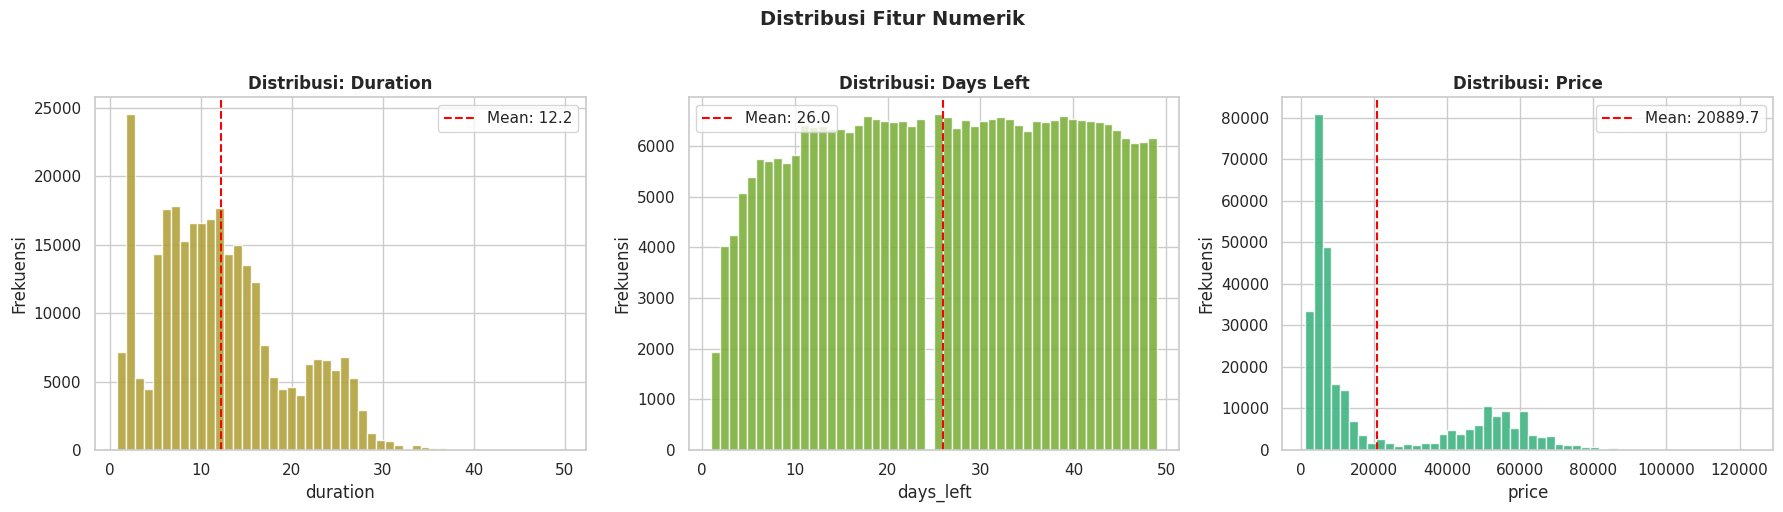

In [ ]:
num_cols = ['duration', 'days_left', 'price']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, color=colors_palette[i+2], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend()

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

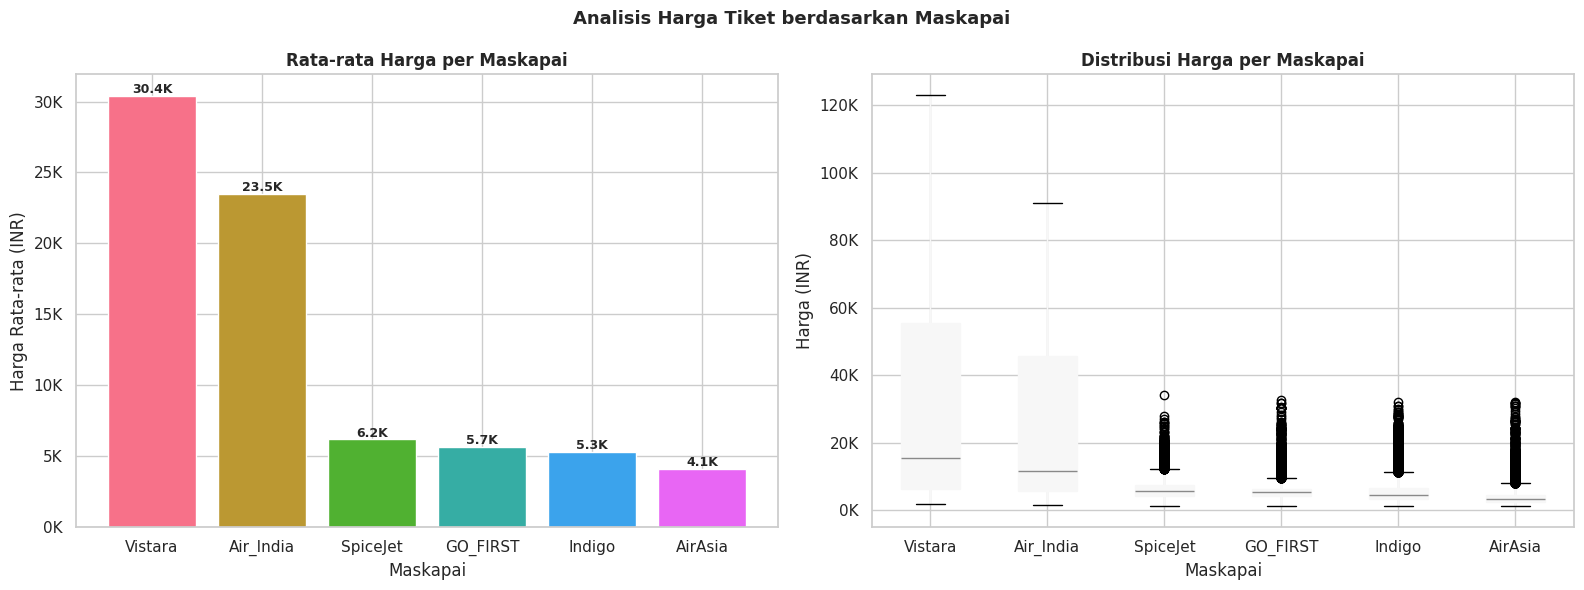


Statistik Harga per Maskapai:


,min,mean,median,max,std
airline,,,,,
Vistara,1714,30397.0,15543.0,123071,25637.0
Air_India,1526,23507.0,11520.0,90970,20905.0
SpiceJet,1106,6179.0,5654.0,34158,3000.0
GO_FIRST,1105,5652.0,5336.0,32803,2514.0
Indigo,1105,5324.0,4453.0,31952,3269.0
AirAsia,1105,4091.0,3276.0,31917,2824.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean price per airline
airline_price = df.groupby('airline')['price'].mean().sort_values(ascending=False)
bars = axes[0].bar(airline_price.index, airline_price.values,
                   color=sns.color_palette('husl', len(airline_price)), edgecolor='white')
axes[0].set_title('Rata-rata Harga per Maskapai', fontweight='bold')
axes[0].set_ylabel('Harga Rata-rata (INR)')
axes[0].set_xlabel('Maskapai')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars, airline_price.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val/1000:.1f}K', ha='center', fontsize=9, fontweight='bold')

# Boxplot price per airline
airline_order = df.groupby('airline')['price'].median().sort_values(ascending=False).index.tolist()
df_ordered = df.copy()
df_ordered['airline'] = pd.Categorical(df_ordered['airline'], categories=airline_order, ordered=True)
df_ordered.sort_values('airline').boxplot(column='price', by='airline', ax=axes[1], patch_artist=True)
axes[1].set_title('Distribusi Harga per Maskapai', fontweight='bold')
axes[1].set_xlabel('Maskapai')
axes[1].set_ylabel('Harga (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.suptitle('Analisis Harga Tiket berdasarkan Maskapai', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStatistik Harga per Maskapai:")
df.groupby('airline')['price'].agg(['min','mean','median','max','std']).round(0).sort_values('mean', ascending=False)

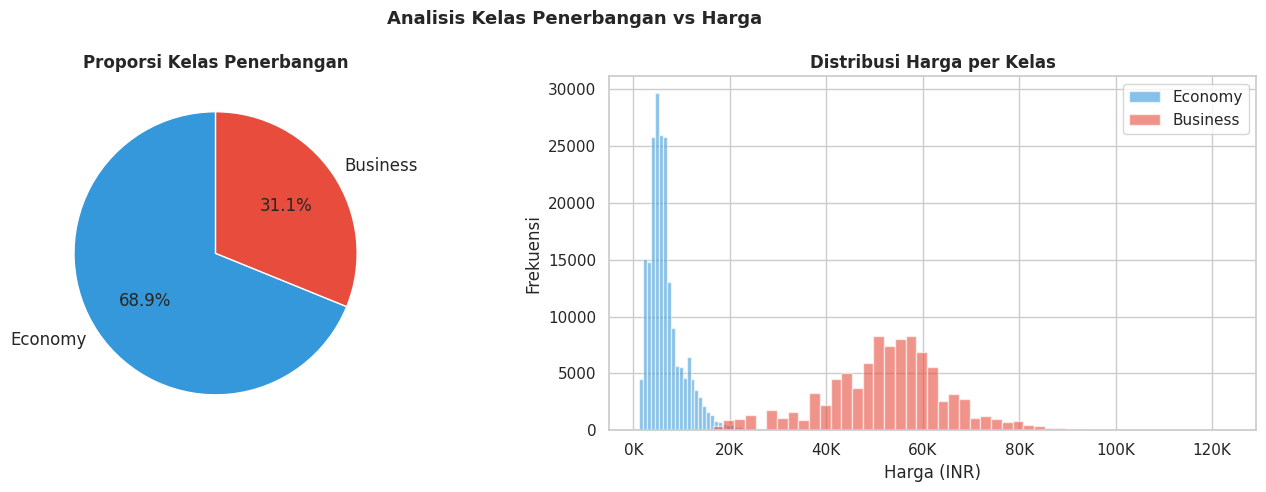


Statistik Harga per Kelas Penerbangan:


,min,mean,median,max
class,,,,
Business,12000,52540.0,53164.0,123071
Economy,1105,6572.0,5772.0,42349


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart proporsi kelas
class_counts = df['class'].value_counts()
axes[0].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Proporsi Kelas Penerbangan', fontweight='bold')

# Boxplot per kelas
for cls, color in zip(['Economy', 'Business'], ['#3498db', '#e74c3c']):
    data = df[df['class'] == cls]['price']
    axes[1].hist(data, bins=50, alpha=0.6, label=cls, color=color, edgecolor='white')
axes[1].set_title('Distribusi Harga per Kelas', fontweight='bold')
axes[1].set_xlabel('Harga (INR)')
axes[1].set_ylabel('Frekuensi')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].legend()

plt.suptitle('Analisis Kelas Penerbangan vs Harga', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStatistik Harga per Kelas Penerbangan:")
df.groupby('class')['price'].agg(['min','mean','median','max']).round(0)

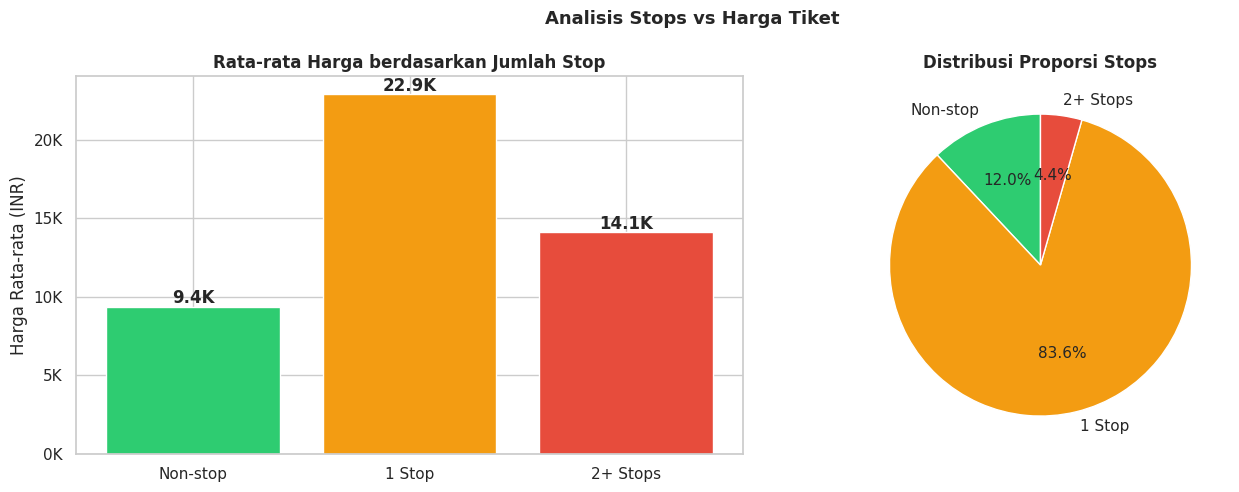


Statistik Harga per Jumlah Stop:


,min,mean,median,max
stops,,,,
zero,1105,9376.0,4499.0,59573
one,1105,22901.0,7959.0,123071
two_or_more,1966,14113.0,8307.0,117307


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stops_order = ['zero', 'one', 'two_or_more']
stops_labels = ['Non-stop', '1 Stop', '2+ Stops']

# Mean price per stops
stops_price = df.groupby('stops')['price'].mean().reindex(stops_order)
bars = axes[0].bar(stops_labels, stops_price.values,
                   color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[0].set_title('Rata-rata Harga berdasarkan Jumlah Stop', fontweight='bold')
axes[0].set_ylabel('Harga Rata-rata (INR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars, stops_price.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val/1000:.1f}K', ha='center', fontweight='bold')

# Pie chart stops distribution
stops_counts = df['stops'].value_counts().reindex(stops_order)
axes[1].pie(stops_counts.values, labels=stops_labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Distribusi Proporsi Stops', fontweight='bold')

plt.suptitle('Analisis Stops vs Harga Tiket', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStatistik Harga per Jumlah Stop:")
df.groupby('stops')['price'].agg(['min','mean','median','max']).round(0).reindex(stops_order)

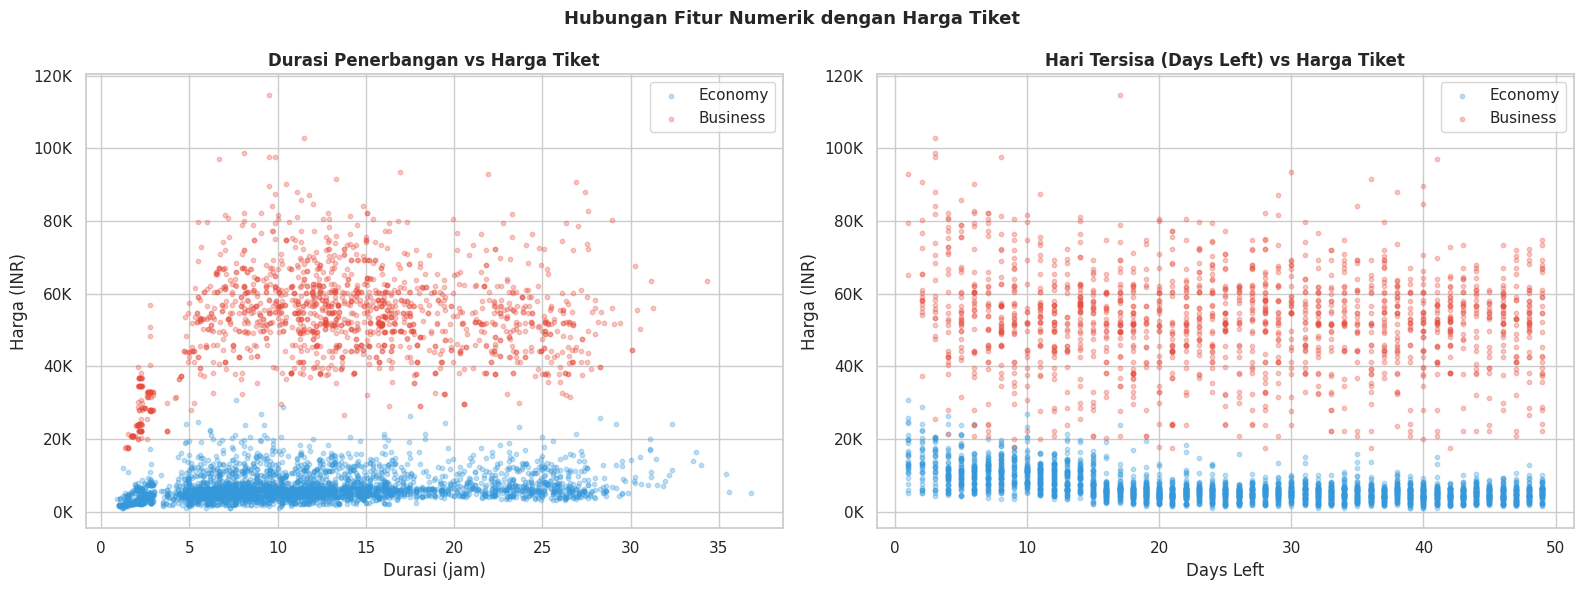

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample for scatter plot performance
sample = df.sample(5000, random_state=42)

# Duration vs Price (by class)
for cls, color in zip(['Economy', 'Business'], ['#3498db', '#e74c3c']):
    mask = sample['class'] == cls
    axes[0].scatter(sample[mask]['duration'], sample[mask]['price'],
                    alpha=0.3, label=cls, color=color, s=10)
axes[0].set_title('Durasi Penerbangan vs Harga Tiket', fontweight='bold')
axes[0].set_xlabel('Durasi (jam)')
axes[0].set_ylabel('Harga (INR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend()

# Days left vs Price
for cls, color in zip(['Economy', 'Business'], ['#3498db', '#e74c3c']):
    mask = sample['class'] == cls
    axes[1].scatter(sample[mask]['days_left'], sample[mask]['price'],
                    alpha=0.3, label=cls, color=color, s=10)
axes[1].set_title('Hari Tersisa (Days Left) vs Harga Tiket', fontweight='bold')
axes[1].set_xlabel('Days Left')
axes[1].set_ylabel('Harga (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].legend()

plt.suptitle('Hubungan Fitur Numerik dengan Harga Tiket', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

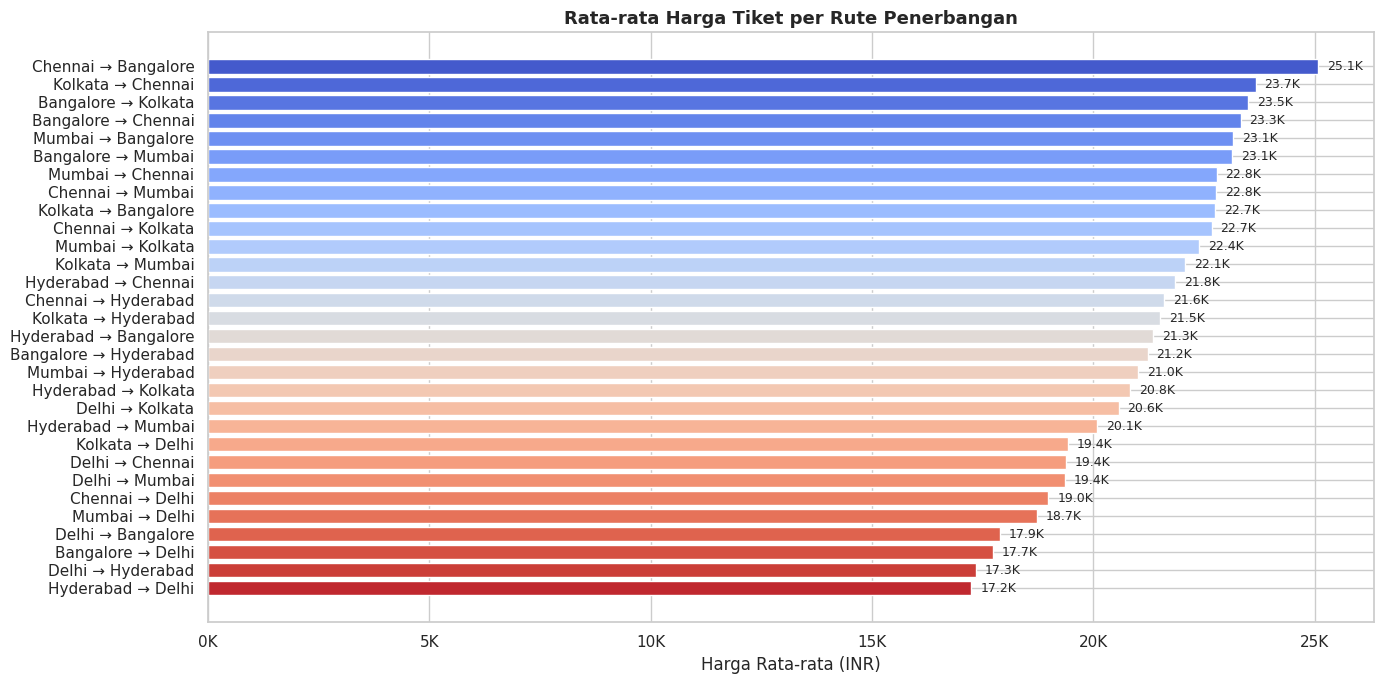

In [ ]:
df['route'] = df['source_city'] + ' → ' + df['destination_city']
route_price = df.groupby('route')['price'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
colors_route = sns.color_palette('coolwarm', len(route_price))
bars = ax.barh(route_price.index, route_price.values, color=colors_route, edgecolor='white')
ax.set_title('Rata-rata Harga Tiket per Rute Penerbangan', fontsize=13, fontweight='bold')
ax.set_xlabel('Harga Rata-rata (INR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars, route_price.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.1f}K', va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Drop route helper column
df.drop(columns=['route'], inplace=True)

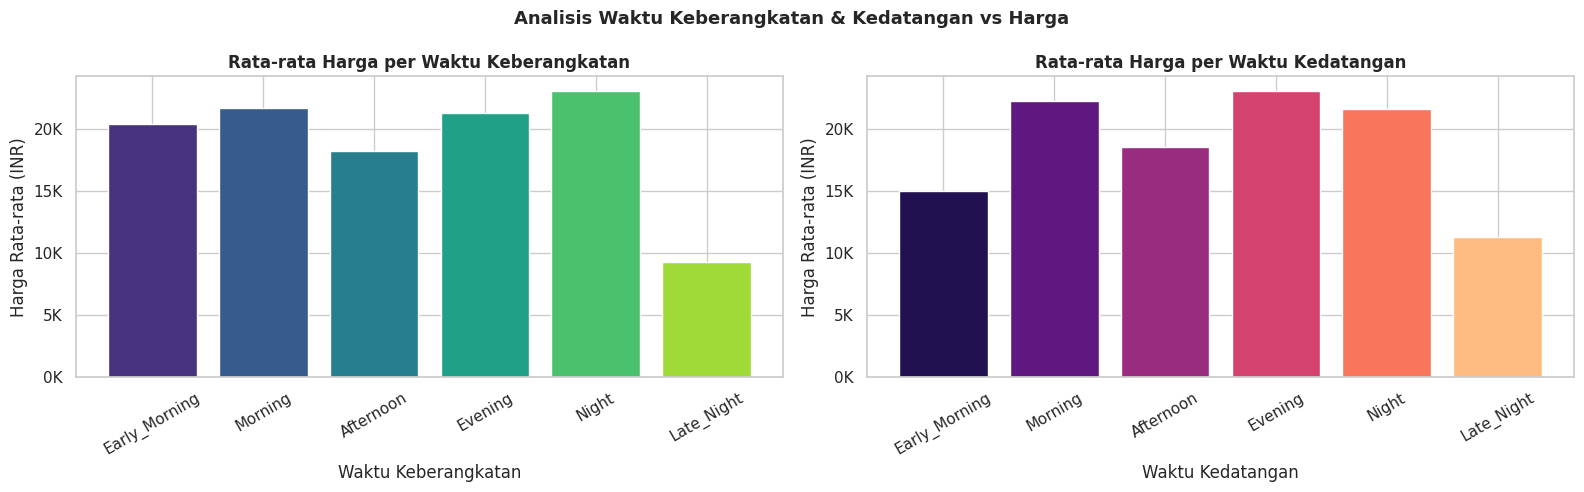

In [ ]:
time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Departure time price
dep_price = df.groupby('departure_time')['price'].mean().reindex(time_order)
bars = axes[0].bar(dep_price.index, dep_price.values,
                   color=sns.color_palette('viridis', len(dep_price)), edgecolor='white')
axes[0].set_title('Rata-rata Harga per Waktu Keberangkatan', fontweight='bold')
axes[0].set_ylabel('Harga Rata-rata (INR)')
axes[0].set_xlabel('Waktu Keberangkatan')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=30)

# Arrival time price
arr_price = df.groupby('arrival_time')['price'].mean().reindex(time_order)
bars2 = axes[1].bar(arr_price.index, arr_price.values,
                    color=sns.color_palette('magma', len(arr_price)), edgecolor='white')
axes[1].set_title('Rata-rata Harga per Waktu Kedatangan', fontweight='bold')
axes[1].set_ylabel('Harga Rata-rata (INR)')
axes[1].set_xlabel('Waktu Kedatangan')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Analisis Waktu Keberangkatan & Kedatangan vs Harga', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

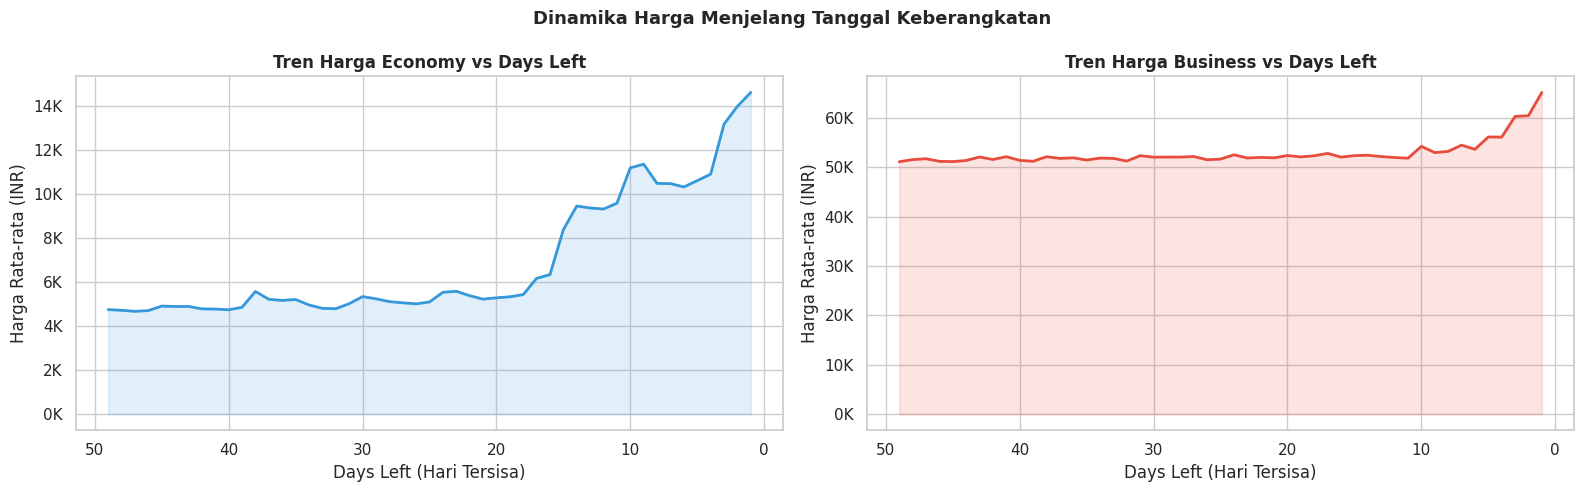

Insight: Harga cenderung meningkat ketika mendekati tanggal keberangkatan (days_left kecil)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Economy
eco = df[df['class'] == 'Economy'].groupby('days_left')['price'].mean()
axes[0].plot(eco.index, eco.values, color='#3498db', linewidth=2)
axes[0].fill_between(eco.index, eco.values, alpha=0.15, color='#3498db')
axes[0].set_title('Tren Harga Economy vs Days Left', fontweight='bold')
axes[0].set_xlabel('Days Left (Hari Tersisa)')
axes[0].set_ylabel('Harga Rata-rata (INR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].invert_xaxis()

# Business
biz = df[df['class'] == 'Business'].groupby('days_left')['price'].mean()
axes[1].plot(biz.index, biz.values, color='#e74c3c', linewidth=2)
axes[1].fill_between(biz.index, biz.values, alpha=0.15, color='#e74c3c')
axes[1].set_title('Tren Harga Business vs Days Left', fontweight='bold')
axes[1].set_xlabel('Days Left (Hari Tersisa)')
axes[1].set_ylabel('Harga Rata-rata (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].invert_xaxis()

plt.suptitle('Dinamika Harga Menjelang Tanggal Keberangkatan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight: Harga cenderung meningkat ketika mendekati tanggal keberangkatan (days_left kecil)")

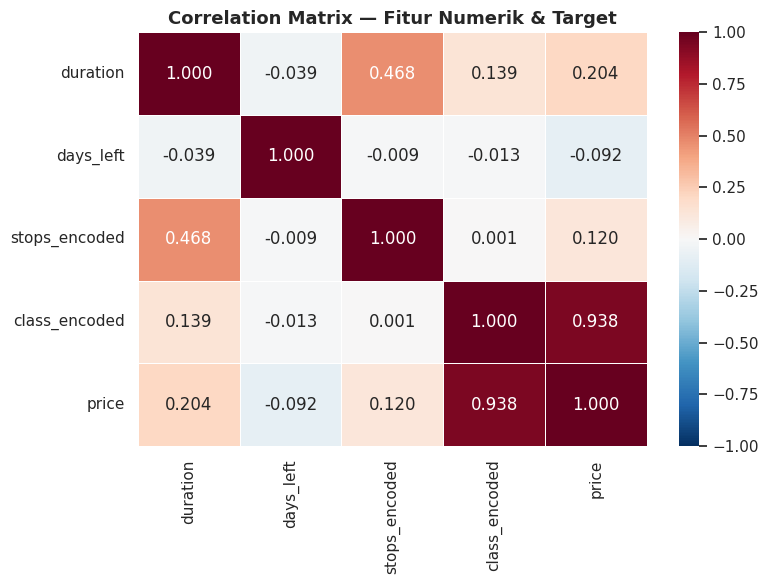


Korelasi dengan Price (Target):
class_encoded    0.938
duration         0.204
stops_encoded    0.120
days_left       -0.092
Name: price, dtype: float64


In [ ]:
# Encode stops for correlation
stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
class_map = {'Economy': 0, 'Business': 1}

df_corr = df.copy()
df_corr['stops_encoded'] = df_corr['stops'].map(stops_map)
df_corr['class_encoded'] = df_corr['class'].map(class_map)

corr_cols = ['duration', 'days_left', 'stops_encoded', 'class_encoded', 'price']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Correlation Matrix — Fitur Numerik & Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKorelasi dengan Price (Target):")
print(corr_matrix['price'].sort_values(ascending=False).drop('price').round(3))

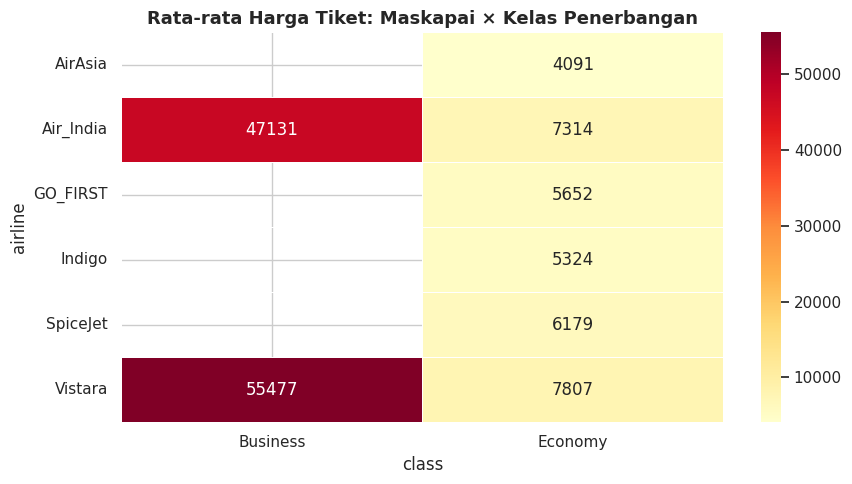

In [ ]:
pivot_airline_class = df.pivot_table(values='price', index='airline', columns='class', aggfunc='mean')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_airline_class, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Rata-rata Harga Tiket: Maskapai × Kelas Penerbangan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

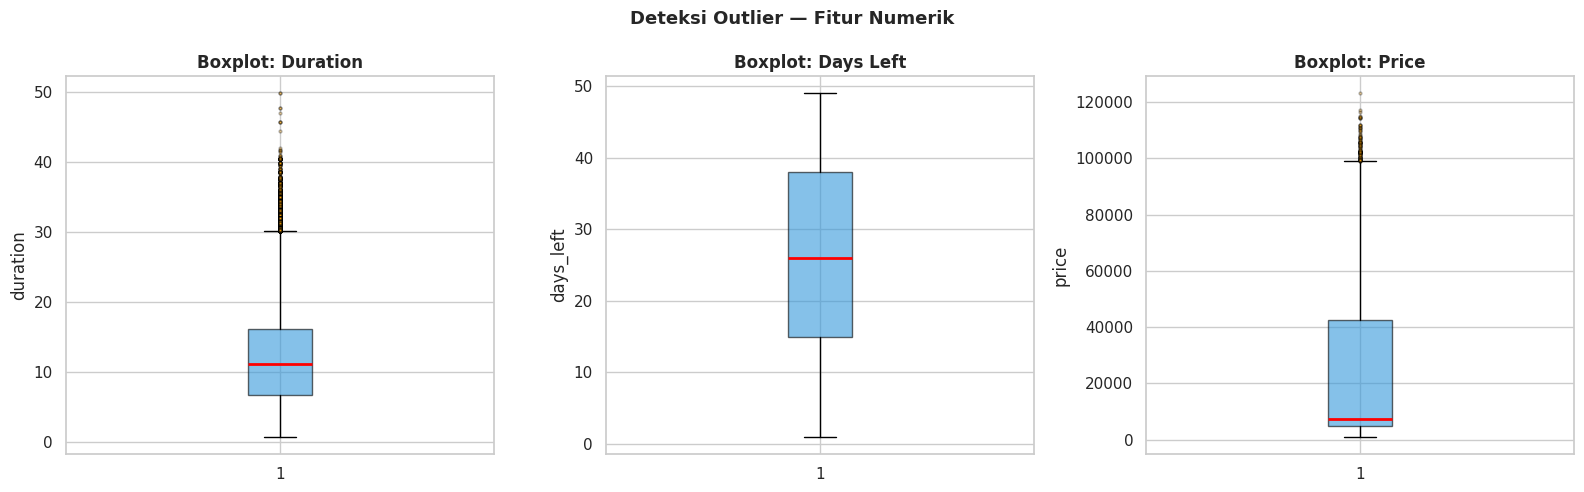


Analisis Outlier menggunakan IQR Method:
  [duration] IQR Range: [-7.18, 30.18] | Outliers: 2,110 (0.70%)
  [days_left] IQR Range: [-19.50, 72.50] | Outliers: 0 (0.00%)
  [price] IQR Range: [-51824.00, 99128.00] | Outliers: 123 (0.04%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=2, alpha=0.3))
    axes[i].set_title(f'Boxplot: {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Deteksi Outlier — Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR method
print("\nAnalisis Outlier menggunakan IQR Method:")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct = outliers / len(df) * 100
    print(f"  [{col}] IQR Range: [{lower:.2f}, {upper:.2f}] | Outliers: {outliers:,} ({pct:.2f}%)")

#Data Preprocessing

In [ ]:
df.drop(columns=['flight'], inplace=True)
print(f'Kolom "flight" di-drop.')
print(f'Kolom tersisa: {df.columns.tolist()}')
print(f'Shape: {df.shape}')

Kolom "flight" di-drop.
Kolom tersisa: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']
Shape: (300153, 10)


In [ ]:
print('Distribusi Price per Class sebelum Handling Outlier:')
print(df.groupby('class')['price'].describe().round(0))

Distribusi Price per Class sebelum Handling Outlier:
             count     mean      std      min      25%      50%      75%  \
class                                                                      
Business   93487.0  52540.0  12969.0  12000.0  45185.0  53164.0  60396.0   
Economy   206666.0   6572.0   3744.0   1105.0   4173.0   5772.0   7746.0   

               max  
class               
Business  123071.0  
Economy    42349.0  


In [ ]:
def remove_outliers_iqr(data, column, multiplier=3.0):
    """Hapus outlier menggunakan IQR method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower  = Q1 - multiplier * IQR
    upper  = Q3 + multiplier * IQR
    before = len(data)
    data   = data[(data[column] >= lower) & (data[column] <= upper)]
    print(f'  [{column}] Batas: [{lower:.0f}, {upper:.0f}] | Dihapus: {before - len(data):,} baris')
    return data

print('Handling Outlier per Kelas (IQR multiplier=3.0):')
eco_df = df[df['class'] == 'Economy'].copy()
biz_df = df[df['class'] == 'Business'].copy()

eco_df = remove_outliers_iqr(eco_df, 'price', multiplier=3.0)
eco_df = remove_outliers_iqr(eco_df, 'duration', multiplier=3.0)
biz_df = remove_outliers_iqr(biz_df, 'price', multiplier=3.0)
biz_df = remove_outliers_iqr(biz_df, 'duration', multiplier=3.0)

df_clean = pd.concat([eco_df, biz_df]).reset_index(drop=True)
print(f'\nShape setelah outlier handling: {df_clean.shape} ({len(df_clean)/len(df)*100:.1f}% data tersisa)')

Handling Outlier per Kelas (IQR multiplier=3.0):
  [price] Batas: [-6546, 18465] | Dihapus: 2,833 baris
  [duration] Batas: [-21, 42] | Dihapus: 5 baris
  [price] Batas: [-448, 106029] | Dihapus: 34 baris
  [duration] Batas: [-18, 45] | Dihapus: 2 baris

Shape setelah outlier handling: (297279, 10) (99.0% data tersisa)


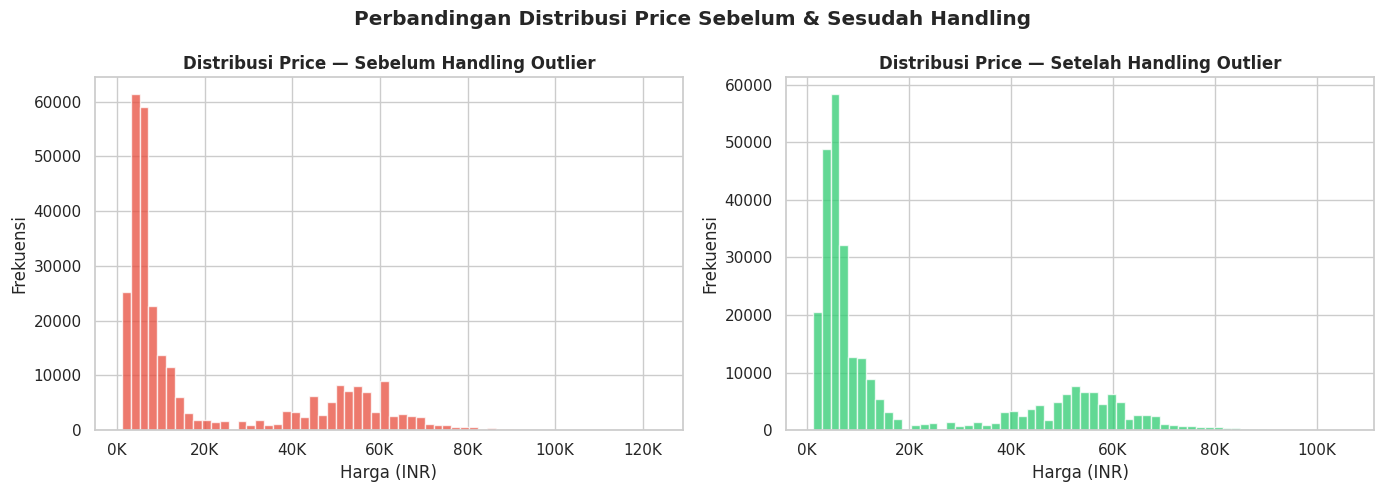

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=60, color='#e74c3c', alpha=0.75, edgecolor='white')
axes[0].set_title('Distribusi Price — Sebelum Handling Outlier', fontweight='bold')
axes[0].set_xlabel('Harga (INR)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].hist(df_clean['price'], bins=60, color='#2ecc71', alpha=0.75, edgecolor='white')
axes[1].set_title('Distribusi Price — Setelah Handling Outlier', fontweight='bold')
axes[1].set_xlabel('Harga (INR)')
axes[1].set_ylabel('Frekuensi')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Perbandingan Distribusi Price Sebelum & Sesudah Handling', fontweight='bold')
plt.tight_layout()
plt.show()

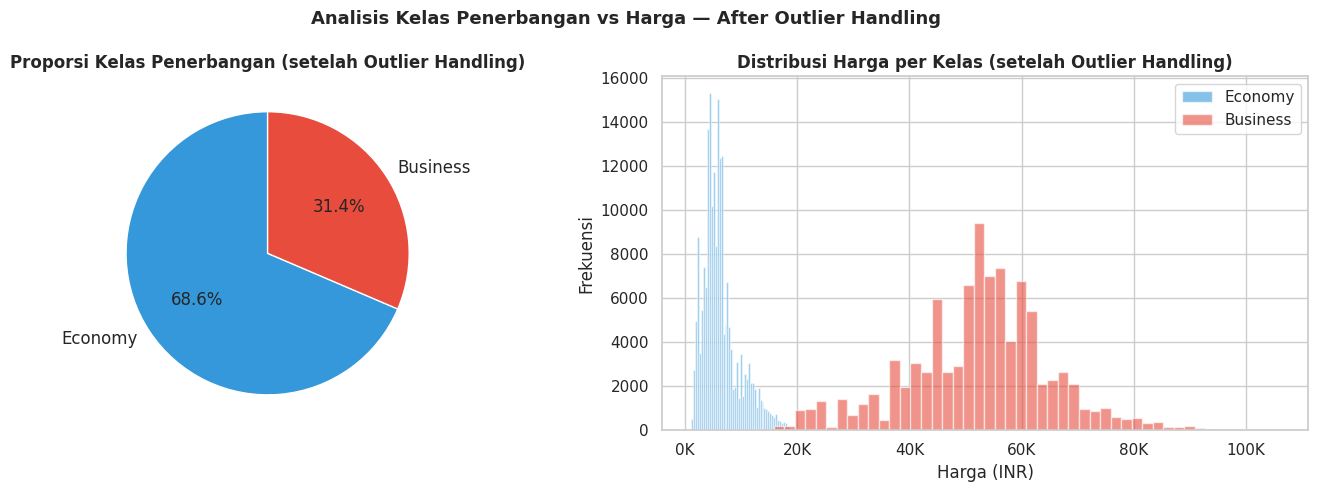


Statistik Harga per Kelas (setelah Outlier Handling):


,min,mean,median,max
class,,,,
Business,12000,52519.0,53164.0,105961
Economy,1105,6360.0,5748.0,18462


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart proporsi kelas
class_counts = df_clean['class'].value_counts()
axes[0].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Proporsi Kelas Penerbangan (setelah Outlier Handling)', fontweight='bold')

# Histogram per kelas
for cls, color in zip(['Economy', 'Business'], ['#3498db', '#e74c3c']):
    data = df_clean[df_clean['class'] == cls]['price']
    axes[1].hist(data, bins=50, alpha=0.6, label=cls, color=color, edgecolor='white')
axes[1].set_title('Distribusi Harga per Kelas (setelah Outlier Handling)', fontweight='bold')
axes[1].set_xlabel('Harga (INR)')
axes[1].set_ylabel('Frekuensi')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].legend()

plt.suptitle('Analisis Kelas Penerbangan vs Harga — After Outlier Handling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStatistik Harga per Kelas (setelah Outlier Handling):")
df_clean.groupby('class')['price'].agg(['min','mean','median','max']).round(0)

#Feature Engineering & Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
df_fe = df_clean.copy()

df_fe['stops'] = df_fe['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

time_map = {'Early_Morning': 0, 'Morning': 1, 'Afternoon': 2,
            'Evening': 3, 'Night': 4, 'Late_Night': 5}
df_fe['departure_time'] = df_fe['departure_time'].map(time_map)
df_fe['arrival_time']   = df_fe['arrival_time'].map(time_map)

df_fe['class'] = df_fe['class'].map({'Economy': 0, 'Business': 1})

airline_map = {'SpiceJet': 0, 'AirAsia': 1, 'GO_FIRST': 2,
               'Indigo': 3, 'Air_India': 4, 'Vistara': 5}
df_fe['airline'] = df_fe['airline'].map(airline_map)

le = LabelEncoder()
df_fe['source_city']      = le.fit_transform(df_fe['source_city'])
df_fe['destination_city'] = le.fit_transform(df_fe['destination_city'])

df_fe['is_offpeak'] = df_fe['departure_time'].apply(lambda x: 1 if x in [0, 5] else 0)

df_fe['urgency'] = pd.cut(df_fe['days_left'],
                           bins=[0, 7, 20, 50],
                           labels=[2, 1, 0]).astype(int)

df_fe['duration_cat'] = pd.cut(df_fe['duration'],
                                bins=[0, 3, 8, 20, 60],
                                labels=[0, 1, 2, 3]).astype(int)

print('Feature Engineering selesai!')
print(f'Shape akhir: {df_fe.shape}')
print(f'Missing values: {df_fe.isnull().sum().sum()}')
df_fe.head(3)

Feature Engineering selesai!
Shape akhir: (297279, 13)
Missing values: 0


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,is_offpeak,urgency,duration_cat
0,0,2,3,0,4,5,0,2.17,1,5953,0,2,0
1,0,2,0,0,1,5,0,2.33,1,5953,1,2,0
2,1,2,0,0,0,5,0,2.17,1,5956,1,2,0


#Correlation Matrix setelah Feature Engineering

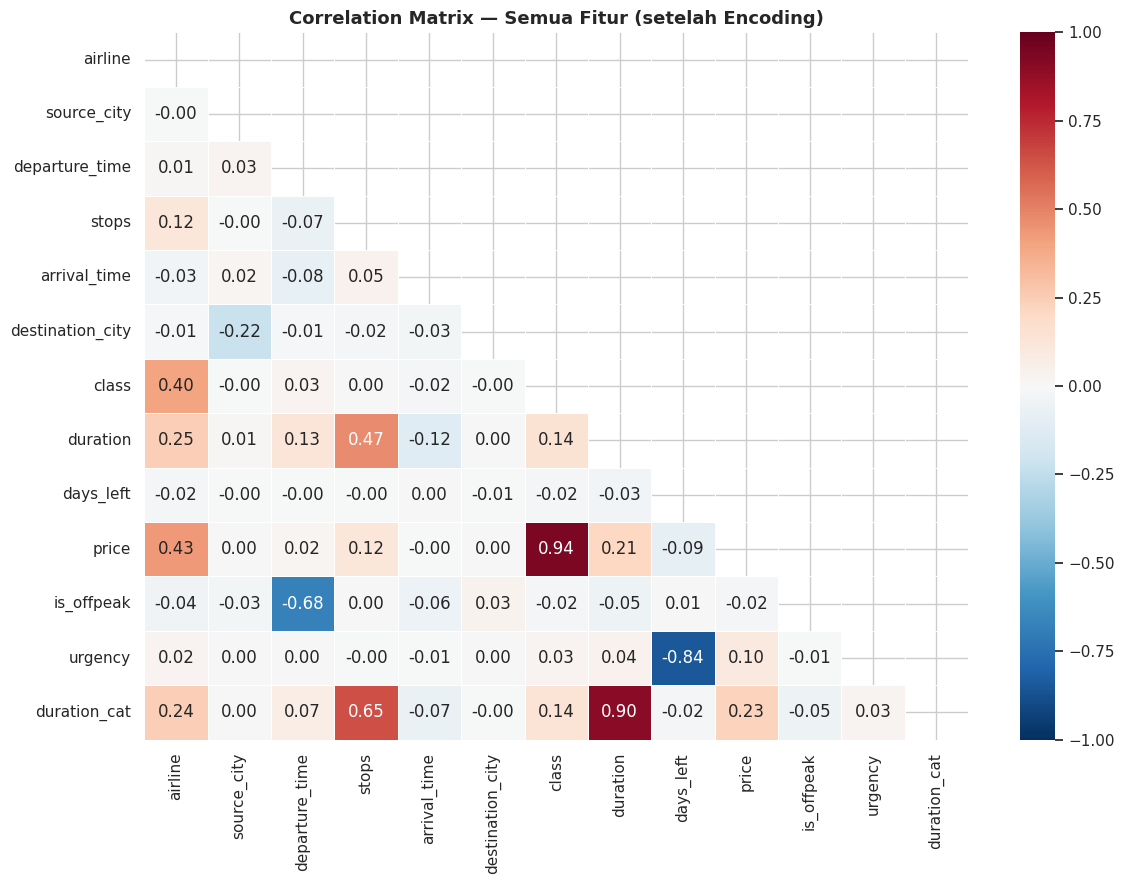


Korelasi dengan Target (price):
class               0.941
airline             0.430
duration_cat        0.228
duration            0.205
stops               0.120
urgency             0.099
departure_time      0.021
destination_city    0.005
source_city         0.005
arrival_time       -0.001
is_offpeak         -0.018
days_left          -0.092


In [ ]:
corr = df_fe.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, mask=mask)
ax.set_title('Correlation Matrix — Semua Fitur (setelah Encoding)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKorelasi dengan Target (price):')
print(corr['price'].sort_values(ascending=False).drop('price').round(3).to_string())

#Korelasi Fitur (setelah Encoding) dengan Price

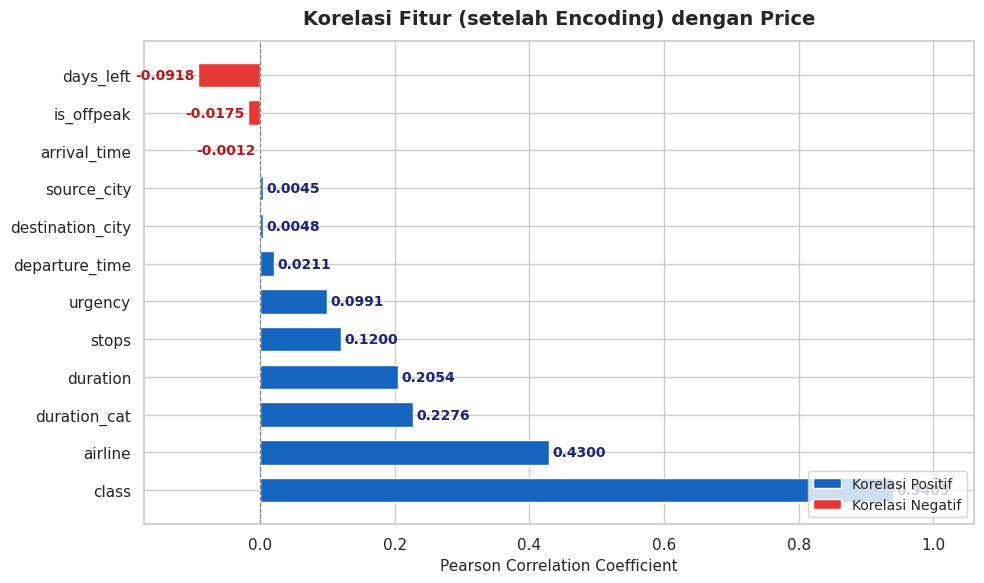


Korelasi dengan Price (diurutkan):
class               0.9405
airline             0.4300
duration_cat        0.2276
duration            0.2054
stops               0.1200
urgency             0.0991
departure_time      0.0211
destination_city    0.0048
source_city         0.0045
arrival_time       -0.0012
is_offpeak         -0.0175
days_left          -0.0918


In [ ]:
C_BLUE = '#1565C0'

corr_price = df_fe.corr()['price'].drop('price').sort_values(ascending=False)
colors = [C_BLUE if v > 0 else '#E53935' for v in corr_price.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corr_price.index, corr_price.values, color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, corr_price.values):
    ha   = 'left'  if val >= 0 else 'right'
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha=ha, fontsize=10, fontweight='bold',
            color='#1A237E' if val >= 0 else '#B71C1C')

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Korelasi Fitur (setelah Encoding) dengan Price',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=11)
ax.set_xlim(corr_price.min() - 0.08, corr_price.max() + 0.12)
ax.tick_params(axis='y', labelsize=11)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=C_BLUE,    label='Korelasi Positif'),
                   Patch(facecolor='#E53935', label='Korelasi Negatif')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print('\nKorelasi dengan Price (diurutkan):')
print(corr_price.round(4).to_string())


#Train-Test Split

In [ ]:
FEATURES = ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
            'destination_city', 'class', 'duration', 'days_left',
            'is_offpeak', 'urgency', 'duration_cat']
TARGET   = 'price'

X = df_fe[FEATURES]
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('=' * 45)
print('         TRAIN-TEST SPLIT (80/20)')
print('=' * 45)
print(f'  Total data  : {len(X):,}')
print(f'  Training    : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Testing     : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')
print(f'  Features    : {len(FEATURES)}')
print('=' * 45)

         TRAIN-TEST SPLIT (80/20)
  Total data  : 297,279
  Training    : 237,823 (80%)
  Testing     : 59,456 (20%)
  Features    : 12


#Baseline Modelling

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'R2_Score': round(r2, 4), 'MAPE_pct': round(mape, 2)}, model, y_pred

models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge Regression'   : Ridge(alpha=1.0),
    'Decision Tree'      : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, max_depth=15,
                                                  random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                      learning_rate=0.1, random_state=42)
}

results       = []
trained_models= {}
predictions   = {}

print('Melatih Baseline Models...\n')
for name, model in models.items():
    print(f'  Training: {name}...')
    result, trained, y_pred = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)
    trained_models[name] = trained
    predictions[name]    = y_pred
    print(f'    R2={result["R2_Score"]:.4f} | RMSE={result["RMSE"]:,.0f} | MAE={result["MAE"]:,.0f}')

results_df = pd.DataFrame(results).sort_values('R2_Score', ascending=False).reset_index(drop=True)
results_df.index += 1
print('\nPerbandingan Baseline Models:')
results_df

Melatih Baseline Models...

  Training: Linear Regression...
    R2=0.9074 | RMSE=6,947 | MAE=4,433
  Training: Ridge Regression...
    R2=0.9074 | RMSE=6,947 | MAE=4,433
  Training: Decision Tree...
    R2=0.9645 | RMSE=4,304 | MAE=2,378
  Training: Random Forest...
    R2=0.9809 | RMSE=3,159 | MAE=1,573
  Training: Gradient Boosting...
    R2=0.9644 | RMSE=4,310 | MAE=2,486

Perbandingan Baseline Models:


,Model,MAE,RMSE,R2_Score,MAPE_pct
1,Random Forest,1572.68,3158.98,0.9809,10.60
2,Decision Tree,2377.94,4303.71,0.9645,16.19
3,Gradient Boosting,2486.18,4309.62,0.9644,17.28
4,Linear Regression,4432.64,6947.19,0.9074,40.98
5,Ridge Regression,4432.68,6947.20,0.9074,40.98


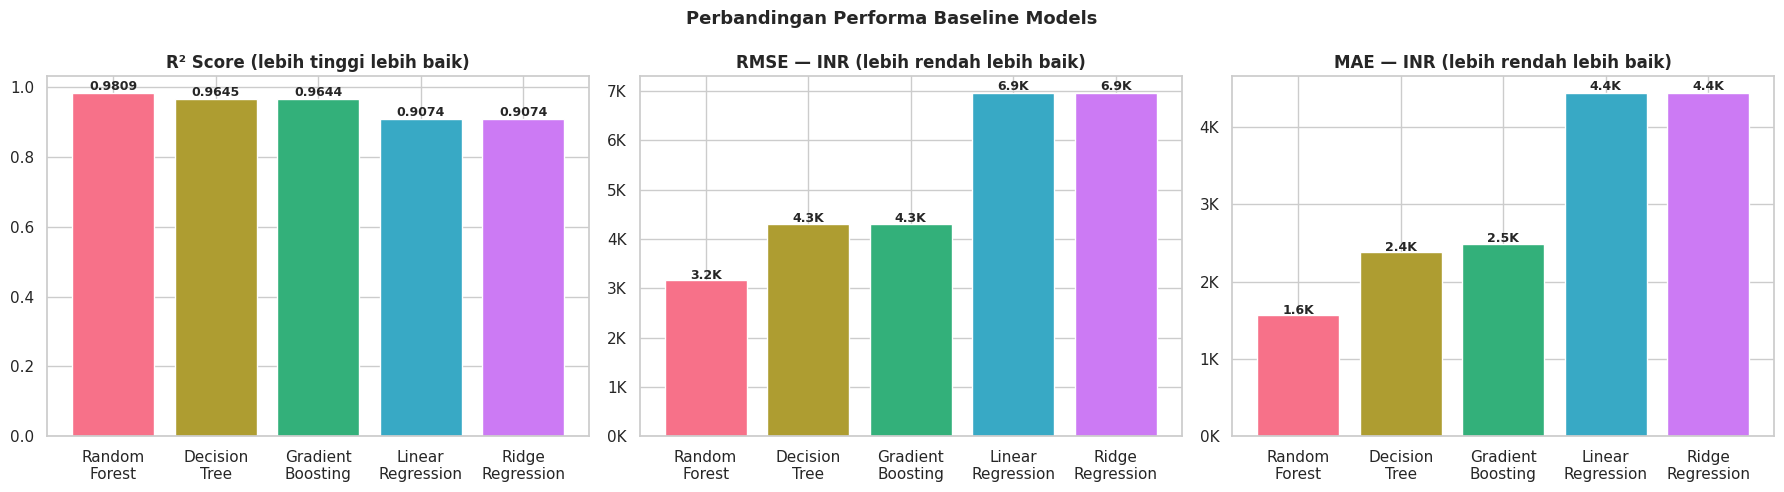

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = sns.color_palette('husl', len(results_df))
model_names_short = [m.replace(' ', '\n') for m in results_df['Model']]

metrics = [('R2_Score', 'R² Score (lebih tinggi lebih baik)', True),
           ('RMSE',     'RMSE — INR (lebih rendah lebih baik)', False),
           ('MAE',      'MAE — INR (lebih rendah lebih baik)', False)]

for ax, (metric, title, higher_better) in zip(axes, metrics):
    bars = ax.bar(model_names_short, results_df[metric], color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    if metric != 'R2_Score':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    for bar, val in zip(bars, results_df[metric]):
        label = f'{val:.4f}' if metric == 'R2_Score' else f'{val/1000:.1f}K'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                label, ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Perbandingan Performa Baseline Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#Hyperparameter Tuning

In [ ]:
print('Hyperparameter Tuning: Random Forest (RandomizedSearchCV, n_iter=20, cv=3)\n')

param_dist_rf = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [10, 15, 20, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
    'bootstrap'         : [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20, cv=3, scoring='r2',
    verbose=1, random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)

print('\nBest Parameters (Random Forest):')
for k, v in rf_search.best_params_.items():
    print(f'  {k:20s}: {v}')
print(f'\nBest CV R² Score: {rf_search.best_score_:.4f}')

Hyperparameter Tuning: Random Forest (RandomizedSearchCV, n_iter=20, cv=3)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters (Random Forest):
  n_estimators        : 300
  min_samples_split   : 5
  min_samples_leaf    : 2
  max_features        : sqrt
  max_depth           : None
  bootstrap           : False

Best CV R² Score: 0.9840


#Tuning Gradient Boosting

In [ ]:
print('Hyperparameter Tuning: Gradient Boosting (RandomizedSearchCV, n_iter=15, cv=3)\n')

param_dist_gb = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 5, 7],
    'learning_rate'     : [0.05, 0.1, 0.2],
    'subsample'         : [0.7, 0.8, 1.0],
    'min_samples_split' : [2, 5, 10]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=15, cv=3, scoring='r2',
    verbose=1, random_state=42, n_jobs=-1
)
gb_search.fit(X_train, y_train)

print('\nBest Parameters (Gradient Boosting):')
for k, v in gb_search.best_params_.items():
    print(f'  {k:20s}: {v}')
print(f'\nBest CV R² Score: {gb_search.best_score_:.4f}')

Hyperparameter Tuning: Gradient Boosting (RandomizedSearchCV, n_iter=15, cv=3)

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Parameters (Gradient Boosting):
  subsample           : 0.8
  n_estimators        : 300
  min_samples_split   : 5
  max_depth           : 7
  learning_rate       : 0.2

Best CV R² Score: 0.9850


In [ ]:
tuned_models = {
    'Random Forest (Tuned)'   : rf_search.best_estimator_,
    'Gradient Boosting (Tuned)': gb_search.best_estimator_
}

tuned_results = []
tuned_preds   = {}

for name, model in tuned_models.items():
    result, _, y_pred = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    tuned_results.append(result)
    tuned_preds[name] = y_pred

tuned_df = pd.DataFrame(tuned_results)
print('Hasil Evaluasi Model Setelah Hyperparameter Tuning:')
tuned_df

Hasil Evaluasi Model Setelah Hyperparameter Tuning:


,Model,MAE,RMSE,R2_Score,MAPE_pct
0,Random Forest (Tuned),1255.75,2797.57,0.9850,8.27
1,Gradient Boosting (Tuned),1487.58,2733.12,0.9857,11.44


In [ ]:
compare_rows = []
for _, row in results_df.iterrows():
    if row['Model'] in ['Random Forest', 'Gradient Boosting']:
        compare_rows.append({**row.to_dict(), 'Stage': 'Baseline'})
for _, row in tuned_df.iterrows():
    compare_rows.append({**row.to_dict(), 'Stage': 'Tuned'})

compare_df = pd.DataFrame(compare_rows).reset_index(drop=True)
print('Perbandingan Baseline vs Tuned:')
compare_df

Perbandingan Baseline vs Tuned:


,Model,MAE,RMSE,R2_Score,MAPE_pct,Stage
0,Random Forest,1572.68,3158.98,0.9809,10.60,Baseline
1,Gradient Boosting,2486.18,4309.62,0.9644,17.28,Baseline
2,Random Forest (Tuned),1255.75,2797.57,0.9850,8.27,Tuned
3,Gradient Boosting (Tuned),1487.58,2733.12,0.9857,11.44,Tuned


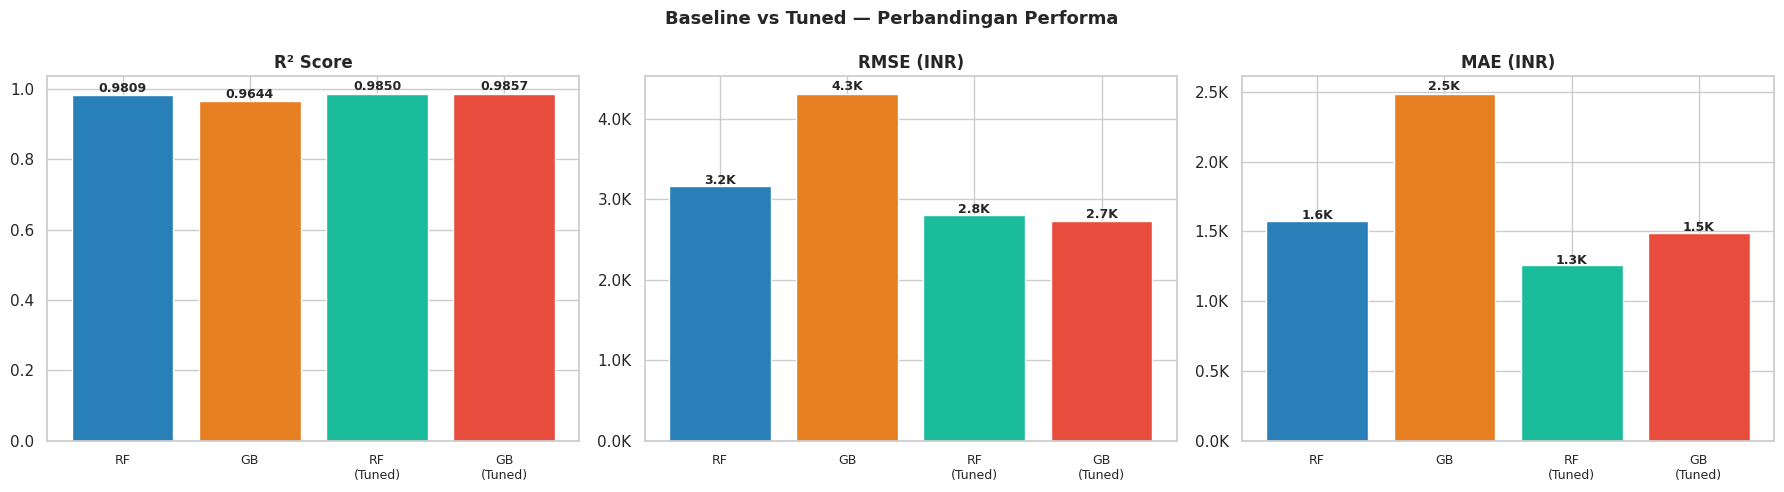

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(compare_df))
bar_colors = ['#2980b9', '#e67e22', '#1abc9c', '#e74c3c']
xlabels = [m.replace('Random Forest', 'RF').replace('Gradient Boosting', 'GB')
             .replace(' (Tuned)', '\n(Tuned)') for m in compare_df['Model']]

for ax, metric, title in zip(axes,
        ['R2_Score', 'RMSE', 'MAE'],
        ['R² Score', 'RMSE (INR)', 'MAE (INR)']):
    bars = ax.bar(x, compare_df[metric], color=bar_colors[:len(compare_df)], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    if metric != 'R2_Score':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}K'))
    for bar, val in zip(bars, compare_df[metric]):
        lv = f'{val:.4f}' if metric == 'R2_Score' else f'{val/1000:.1f}K'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                lv, ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Baseline vs Tuned — Perbandingan Performa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
all_res = list(results_df.itertuples())
all_preds_map = dict(zip(results_df['Model'], [predictions[m] for m in results_df['Model']]))
for _, row in tuned_df.iterrows():
    all_preds_map[row['Model']] = tuned_preds[row['Model']]

all_results_combined = pd.concat([results_df, tuned_df], ignore_index=True)
best_idx   = all_results_combined['R2_Score'].idxmax()
best_row   = all_results_combined.iloc[best_idx]
best_name  = best_row['Model']
best_pred  = all_preds_map[best_name]

print(f'Best Model Keseluruhan: {best_name}')
print(f'  R² Score : {best_row["R2_Score"]:.4f}')
print(f'  RMSE     : INR {best_row["RMSE"]:,.0f}')
print(f'  MAE      : INR {best_row["MAE"]:,.0f}')
print(f'  MAPE     : {best_row["MAPE_pct"]:.2f}%')

Best Model Keseluruhan: Gradient Boosting (Tuned)
  R² Score : 0.9857
  RMSE     : INR 2,733
  MAE      : INR 1,488
  MAPE     : 11.44%


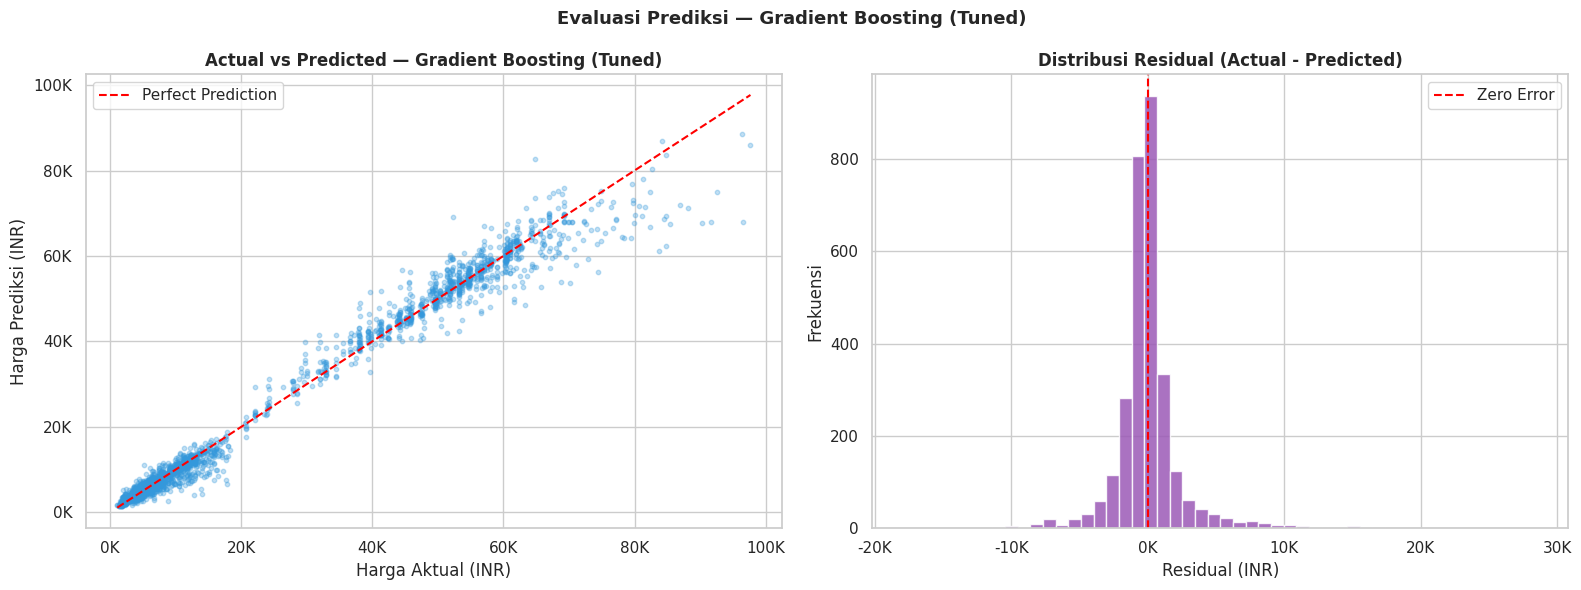

Residual Analysis:
  Mean Residual : 60.51  (ideal: 0)
  Std Residual  : 2,765.97


In [ ]:
np.random.seed(42)
idx_s = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
y_act_s = np.array(y_test)[idx_s]
y_prd_s = best_pred[idx_s]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_act_s, y_prd_s, alpha=0.3, s=10, color='#3498db')
mv = [min(y_act_s.min(), y_prd_s.min()), max(y_act_s.max(), y_prd_s.max())]
axes[0].plot(mv, mv, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted — {best_name}', fontweight='bold')
axes[0].set_xlabel('Harga Aktual (INR)')
axes[0].set_ylabel('Harga Prediksi (INR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend()

residuals = y_act_s - y_prd_s
axes[1].hist(residuals, bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
axes[1].set_title('Distribusi Residual (Actual - Predicted)', fontweight='bold')
axes[1].set_xlabel('Residual (INR)')
axes[1].set_ylabel('Frekuensi')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].legend()

plt.suptitle(f'Evaluasi Prediksi — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Residual Analysis:')
print(f'  Mean Residual : {residuals.mean():,.2f}  (ideal: 0)')
print(f'  Std Residual  : {residuals.std():,.2f}')

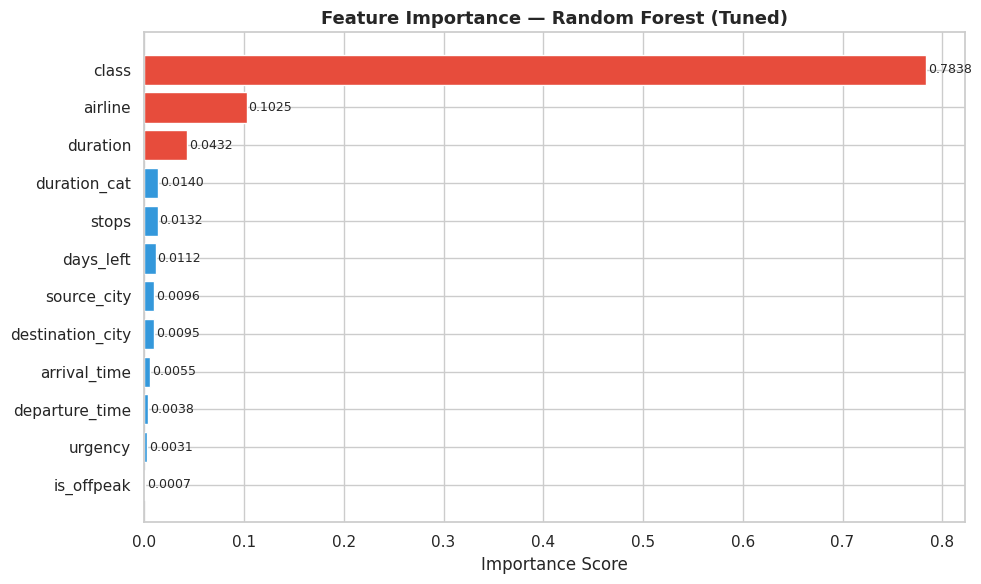

Feature Importance (descending):
class               0.7838
airline             0.1025
duration            0.0432
duration_cat        0.0140
stops               0.0132
days_left           0.0112
source_city         0.0096
destination_city    0.0095
arrival_time        0.0055
departure_time      0.0038
urgency             0.0031
is_offpeak          0.0007


In [ ]:
feat_imp = pd.Series(rf_search.best_estimator_.feature_importances_, index=FEATURES)
feat_imp = feat_imp.sort_values(ascending=True)

colors_fi = ['#e74c3c' if v >= feat_imp.quantile(0.75) else '#3498db' for v in feat_imp]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance — Random Forest (Tuned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Feature Importance (descending):')
print(feat_imp.sort_values(ascending=False).round(4).to_string())

Cross-Validation (5-fold) — Random Forest (Tuned)...

Cross-Validation R² per Fold:
  Fold 1: 0.2524
  Fold 2: -12.6972
  Fold 3: -0.6921
  Fold 4: 0.8566
  Fold 5: -0.8531
  Mean  : -2.6267 ± 5.0740


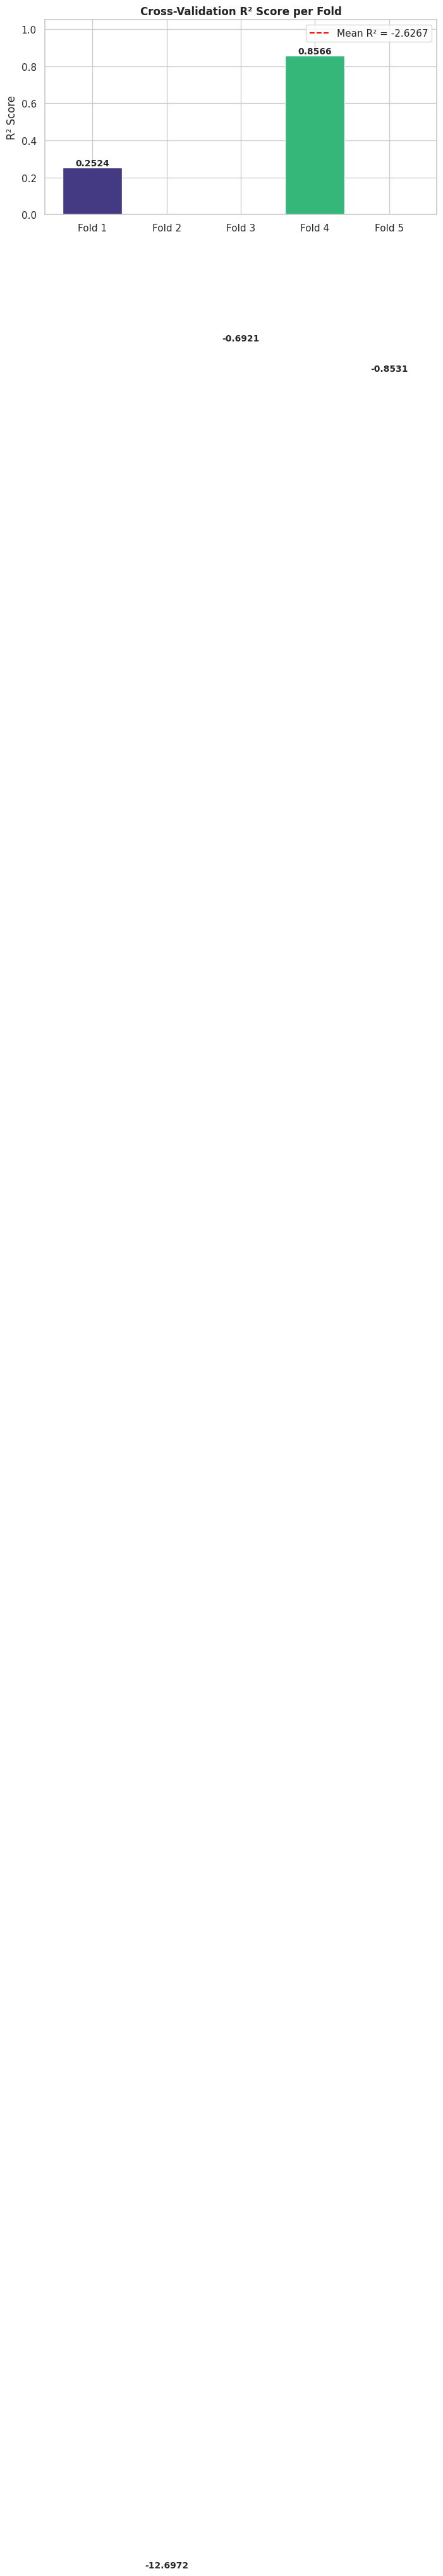

In [ ]:
print('Cross-Validation (5-fold) — Random Forest (Tuned)...')

cv_scores = cross_val_score(
    rf_search.best_estimator_, X, y,
    cv=5, scoring='r2', n_jobs=-1
)

print('\nCross-Validation R² per Fold:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Fold {i}' for i in range(1, 6)],
              cv_scores, color=sns.color_palette('viridis', 5), edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean R² = {cv_scores.mean():.4f}')
ax.set_title('Cross-Validation R² Score per Fold', fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.05)
ax.legend()
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

#Business Use Case Evaluation

In [ ]:
y_pred_all = rf_search.best_estimator_.predict(X_test)

eval_df = X_test.copy()
eval_df['actual']    = y_test.values
eval_df['predicted'] = y_pred_all
eval_df['abs_error'] = np.abs(y_test.values - y_pred_all)
eval_df['pct_error'] = eval_df['abs_error'] / y_test.values * 100
eval_df['class_label'] = eval_df['class'].map({0: 'Economy', 1: 'Business'})

print('Performa Model per Kelas Penerbangan:')
class_perf = eval_df.groupby('class_label').apply(lambda g: pd.Series({
    'Count'     : len(g),
    'MAE'       : mean_absolute_error(g['actual'], g['predicted']),
    'RMSE'      : np.sqrt(mean_squared_error(g['actual'], g['predicted'])),
    'R2_Score'  : r2_score(g['actual'], g['predicted']),
    'MAPE_pct'  : g['pct_error'].mean()
})).round(2)
print(class_perf)

Performa Model per Kelas Penerbangan:
               Count      MAE     RMSE  R2_Score  MAPE_pct
class_label                                               
Business     18713.0  2613.34  4685.78      0.87      4.75
Economy      40743.0   632.22  1156.07      0.88      9.89


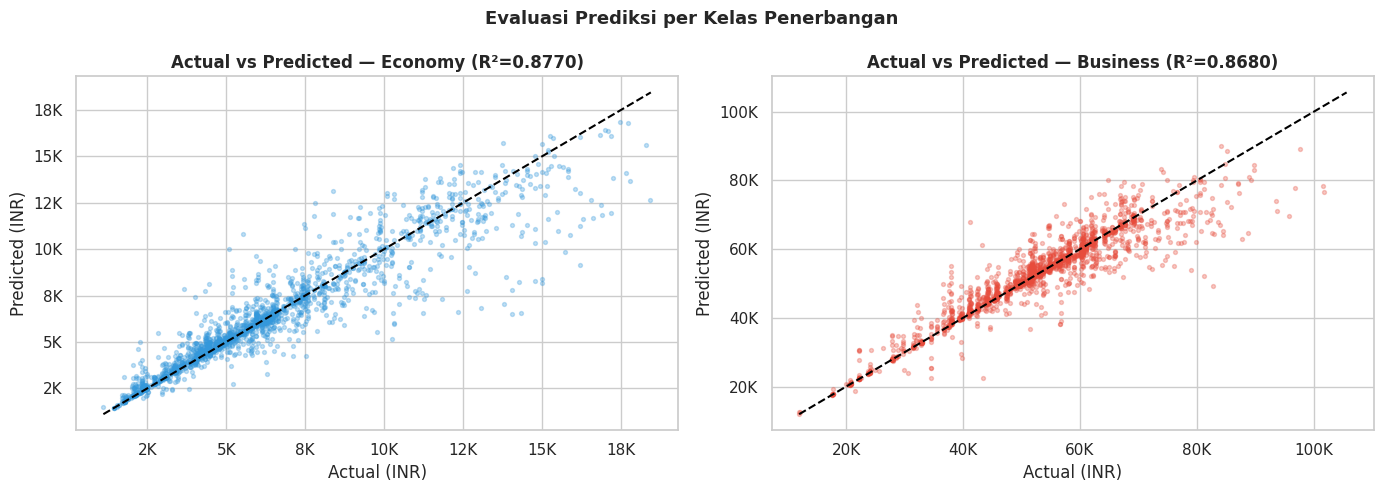

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls_val, cls_name, color, ax in zip([0, 1], ['Economy', 'Business'],
                                         ['#3498db', '#e74c3c'], axes):
    mask = eval_df['class'] == cls_val
    a = eval_df[mask]['actual'].values
    p = eval_df[mask]['predicted'].values
    idx = np.random.choice(len(a), min(2000, len(a)), replace=False)
    ax.scatter(a[idx], p[idx], alpha=0.3, s=8, color=color)
    mv = [min(a.min(), p.min()), max(a.max(), p.max())]
    ax.plot(mv, mv, 'k--', linewidth=1.5)
    ax.set_title(f'Actual vs Predicted — {cls_name} (R²={r2_score(a,p):.4f})', fontweight='bold')
    ax.set_xlabel('Actual (INR)')
    ax.set_ylabel('Predicted (INR)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Evaluasi Prediksi per Kelas Penerbangan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

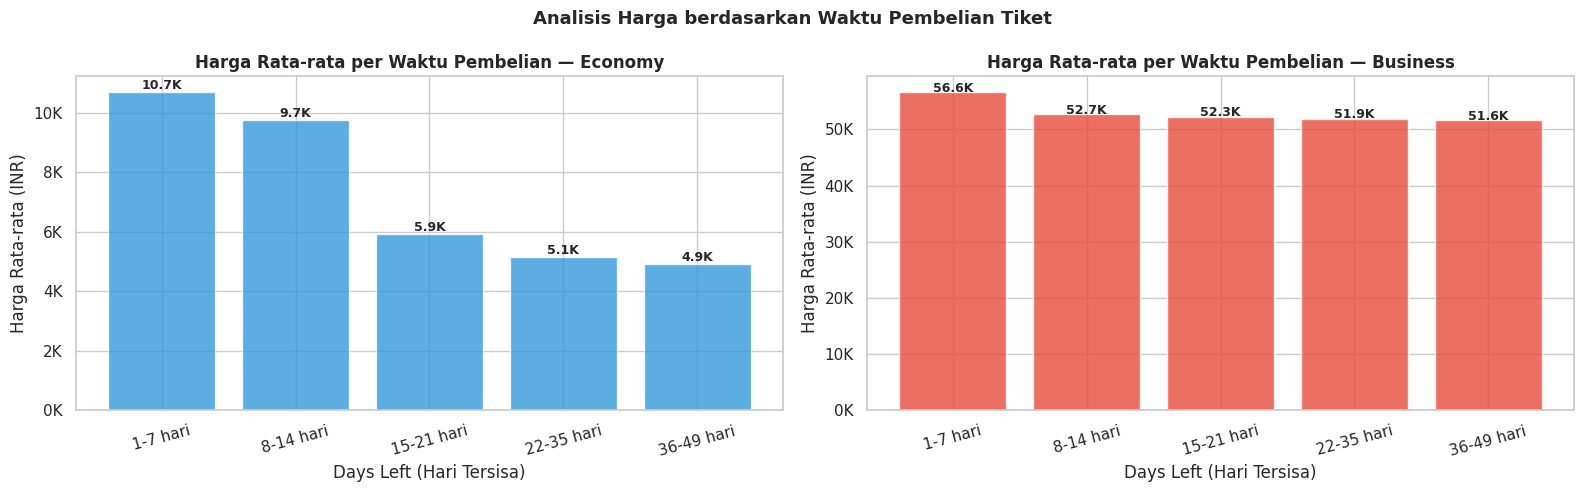

Economy: Beli 1-7 hari = INR 10,681 | 36-49 hari = INR 4,901 | Hemat: INR 5,781 (54.1%)
Business: Beli 1-7 hari = INR 56,620 | 36-49 hari = INR 51,610 | Hemat: INR 5,011 (8.8%)


In [ ]:
df_sim = df_clean.copy()
df_sim['days_bucket'] = pd.cut(df_sim['days_left'],
                                bins=[0, 7, 14, 21, 35, 49],
                                labels=['1-7 hari', '8-14 hari', '15-21 hari', '22-35 hari', '36-49 hari'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, cls_name, color in zip(axes, ['Economy', 'Business'], ['#3498db', '#e74c3c']):
    data = df_sim[df_sim['class'] == cls_name].groupby('days_bucket', observed=True)['price'].mean()
    bars = ax.bar(data.index, data.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Harga Rata-rata per Waktu Pembelian — {cls_name}', fontweight='bold')
    ax.set_xlabel('Days Left (Hari Tersisa)')
    ax.set_ylabel('Harga Rata-rata (INR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val/1000:.1f}K', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Analisis Harga berdasarkan Waktu Pembelian Tiket', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Hitung potensi penghematan
for cls_name in ['Economy', 'Business']:
    d = df_sim[df_sim['class'] == cls_name].groupby('days_bucket', observed=True)['price'].mean()
    hemat = d.iloc[0] - d.iloc[-1]
    pct   = hemat / d.iloc[0] * 100
    print(f'{cls_name}: Beli 1-7 hari = INR {d.iloc[0]:,.0f} | 36-49 hari = INR {d.iloc[-1]:,.0f} | Hemat: INR {hemat:,.0f} ({pct:.1f}%)')

In [ ]:
all_combined = pd.concat([results_df, tuned_df], ignore_index=True)
all_combined = all_combined.sort_values('R2_Score', ascending=False).reset_index(drop=True)
all_combined.index += 1
print('REKAP SEMUA MODEL — Final Comparison:')
all_combined

REKAP SEMUA MODEL — Final Comparison:


,Model,MAE,RMSE,R2_Score,MAPE_pct
1,Gradient Boosting (Tuned),1487.58,2733.12,0.9857,11.44
2,Random Forest (Tuned),1255.75,2797.57,0.9850,8.27
3,Random Forest,1572.68,3158.98,0.9809,10.60
4,Decision Tree,2377.94,4303.71,0.9645,16.19
5,Gradient Boosting,2486.18,4309.62,0.9644,17.28
6,Ridge Regression,4432.68,6947.20,0.9074,40.98
7,Linear Regression,4432.64,6947.19,0.9074,40.98


In [ ]:
best_final = all_combined.iloc[0]

print('=' * 65)
print('   FINAL SUMMARY — CHECK POINT 2 COMPLETE')
print('=' * 65)
print(f'''
Dataset     : India Domestic Flight Price (300K+ records)
Task        : Regression — Prediksi Harga Tiket Pesawat
Metodologi  : CRISP-DM

PREPROCESSING:
  - Drop kolom 'flight' (ID tidak informatif)
  - Handling outlier per kelas dengan IQR (multiplier=3)
  - Ordinal encoding: stops, departure_time, arrival_time
  - Binary encoding: class
  - Label encoding: airline, source_city, destination_city
  - Feature engineering: is_offpeak, urgency, duration_cat
  - Train-Test Split: 80% / 20%

MODEL YANG DIUJI:
  - Linear Regression (baseline)
  - Ridge Regression
  - Decision Tree
  - Random Forest  (+Hyperparameter Tuning)
  - Gradient Boosting (+Hyperparameter Tuning)

BEST MODEL   : {best_final['Model']}
  R² Score   : {best_final['R2_Score']:.4f}
  RMSE       : INR {best_final['RMSE']:,.0f}
  MAE        : INR {best_final['MAE']:,.0f}
  MAPE       : {best_final['MAPE_pct']:.2f}%

TOP FEATURES: class > duration > days_left > airline > stops
''')
print('=' * 65)

   FINAL SUMMARY — CHECK POINT 2 COMPLETE

Dataset     : India Domestic Flight Price (300K+ records)
Task        : Regression — Prediksi Harga Tiket Pesawat
Metodologi  : CRISP-DM

PREPROCESSING:
  - Drop kolom 'flight' (ID tidak informatif)
  - Handling outlier per kelas dengan IQR (multiplier=3)
  - Ordinal encoding: stops, departure_time, arrival_time
  - Binary encoding: class
  - Label encoding: airline, source_city, destination_city
  - Feature engineering: is_offpeak, urgency, duration_cat
  - Train-Test Split: 80% / 20%

MODEL YANG DIUJI:
  - Linear Regression (baseline)
  - Ridge Regression
  - Decision Tree
  - Random Forest  (+Hyperparameter Tuning)
  - Gradient Boosting (+Hyperparameter Tuning)

BEST MODEL   : Gradient Boosting (Tuned)
  R² Score   : 0.9857
  RMSE       : INR 2,733
  MAE        : INR 1,488
  MAPE       : 11.44%

TOP FEATURES: class > duration > days_left > airline > stops

